# 02 — Training & Evaluation

This notebook covers:
1. Loading the processed temporal grid
2. Cross-validated training with GroupKFold
3. Threshold search across all safety zones
4. (Optional) Optuna hyperparameter tuning
5. Final model training and saving
6. Evaluation on the test set

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config.config import (
    FEATURE_COLUMNS, SAFETY_ZONES_KM, RISK_THRESHOLD,
    XGB_DEFAULT_PARAMS, HORIZON_MIN
)
from src.training.model import (
    train_with_cross_validation, smooth_probabilities, train_final_model
)
from src.training.tuning import (
    build_objective_maximize_gain, run_optuna
)
from src.evaluation.metrics import (
    compute_alert_masks, find_best_threshold,
    print_evaluation_report, apply_irrevocable_decision, compute_gain
)
from src.pipeline.predict import save_model, load_model, predict_batch

from config.config import CONFIRMATION_WINDOW

/home/cytech/programmation/data_battle/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load processed grid

In [2]:
## 1. Chargement et préparation

df_train = pd.read_parquet('../data/grid_train.parquet')
df_test  = pd.read_parquet('../data/grid_test.parquet')

# La cible : danger dans les 30 min, zone 20km (cohérent avec l'alerte officielle)
TARGET_COL = f'target_{HORIZON_MIN}m_20km'

features    = [c for c in FEATURE_COLUMNS if c in df_train.columns]
X_all       = df_train[features]
y_all       = df_train[TARGET_COL]
groups_all  = df_train['storm_group_id']

print(f"Dataset: {len(df_train):,} lignes | {groups_all.nunique()} orages")
print(f"Équilibre des classes ({TARGET_COL}) : {y_all.mean():.2%} positif")

Dataset: 209,254 lignes | 2627 orages
Équilibre des classes (target_30m_20km) : 56.58% positif


## 2. Cross-validated training

In [3]:
## 2. Cross-validated training

oof_preds, fold_models = train_with_cross_validation(
    X_all, y_all, groups_all, params=XGB_DEFAULT_PARAMS
)

df_train['proba_brute']  = oof_preds
df_train['proba_lissee'] = smooth_probabilities(df_train, raw_proba_col='proba_brute')

  Pli 1/5...
  Pli 2/5...
  Pli 3/5...
  Pli 4/5...
  Pli 5/5...
Validation croisée terminée.


## 3. Build evaluation masks and threshold search

In [5]:
results = find_best_threshold(
    df_train,
    safety_zones_km=[3],   # [3, 5, 7, 10, 15, 20]
    risk_threshold=RISK_THRESHOLD,
    confirmation_window=CONFIRMATION_WINDOW,
    horizon_min=HORIZON_MIN,
)


In [6]:
# Detailed report for the default audit zone (3 km = jury metric)
print_evaluation_report(results, zone_km=3)

Rapport d’évaluation — zone d’audit : 3 km
  Seuil            : 46.231%
  Gain total       : 41353 minutes
  Risque R         : 1.915%
----------------------------------------------------------------------
  Gain moyen/orage : 15.7 min
  Gain médian      : 15.0 min
  Écart-type       : 11.1 min
  Max / Min        : 208.0 / 0.0 min


## 4. (Optional) Optuna hyperparameter tuning

In [ ]:
RUN_OPTUNA = False

if RUN_OPTUNA:
    objective = build_objective_maximize_gain(X_all, y_all, groups_all, df_train)
    study = run_optuna(
        objective,
        n_trials=10,
        best_known_params=XGB_DEFAULT_PARAMS,
    )
    print('Best params:', study.best_params)

## 5. Final model training

In [7]:
model_final = train_final_model(X_all, y_all, params=XGB_DEFAULT_PARAMS)
save_model(model_final, '../models/xgb_final.pkl')

Entraînement du modèle final sur 100% des données...
Modèle final prêt.
Modèle sauvegardé dans ../models/xgb_final.pkl


## 6. Feature importance

                  Feature  Importance
      activity_drop_ratio    0.466796
minutes_since_last_strike    0.165849
          last_known_dist    0.065443
   activity_count_last_5m    0.058761
     ratio_ic_cg_last_20m    0.025001
     dist_centroid_actuel    0.024389
             dist_last_5m    0.019377
        count_ic_last_20m    0.017652
            cum_n_strikes    0.016797
  activity_count_last_20m    0.015393
        count_cg_last_20m    0.014299
   dist_centroid_proj_30m    0.010121
            dist_last_20m    0.008832
                month_cos    0.008709
                month_sin    0.007697


/tmp/ipykernel_678275/432176608.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance.head(20), palette='viridis')


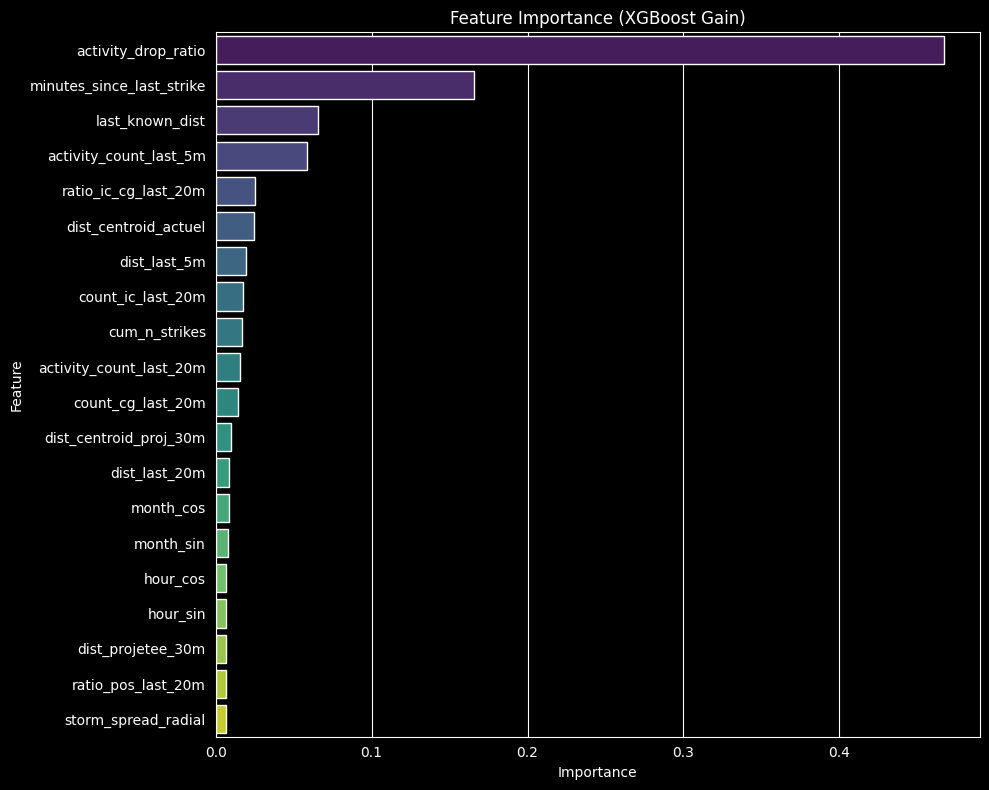

In [8]:
import pandas as pd

df_importance = pd.DataFrame({
    'Feature': features,
    'Importance': model_final.feature_importances_
}).sort_values('Importance', ascending=False)

print(df_importance.head(15).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=df_importance.head(20), palette='viridis')
plt.title('Feature Importance (XGBoost Gain)')
plt.tight_layout()
plt.show()

## 7. Evaluation on test set

In [10]:
results_test = predict_batch(
    model_final,
    df_test,
    safety_zones_km=[3],
    risk_threshold=RISK_THRESHOLD,
)

TypeError: build_temporal_grid() got an unexpected keyword argument 'alert_zone_km'

## 8. Storm visualisation

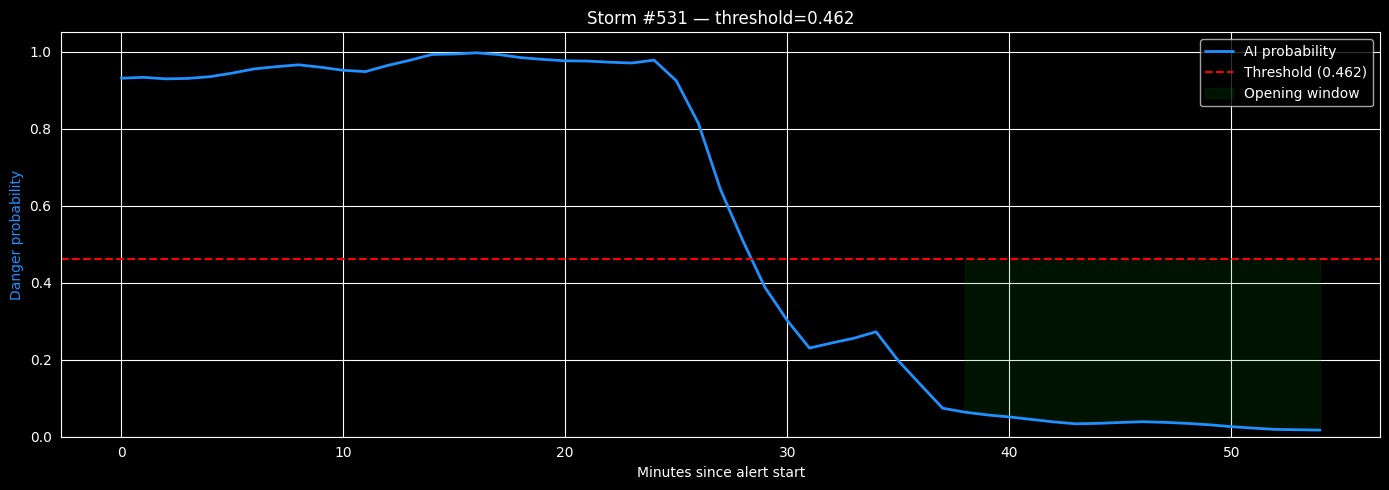

In [9]:
def plot_storm_radar(
    df: pd.DataFrame,
    storm_id: int,
    threshold: float,
    confirmation_window: int = 10,
) -> None:
    """Plot the AI probability curve for a single storm."""
    df_s = df[df['storm_group_id'] == storm_id].copy()
    if df_s.empty:
        print(f"Storm {storm_id} not found.")
        return

    # Trim to alert start
    if 'count_cg_zone' in df_s.columns and df_s['count_cg_zone'].sum() > 0:
        first = df_s[df_s['count_cg_zone'] > 0].index[0]
        df_s = df_s.loc[first:].reset_index(drop=True)

    t = np.arange(len(df_s))
    decision_ia = (df_s['proba_lissee'] > threshold).rolling(window=confirmation_window, min_periods=1).max()

    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax1.plot(t, df_s['proba_lissee'], color='dodgerblue', linewidth=2, label='AI probability')
    ax1.axhline(threshold, color='red', linestyle='--', linewidth=1.5, label=f'Threshold ({threshold:.3f})')
    ax1.fill_between(t, df_s['proba_lissee'], threshold,
                     where=(decision_ia == 0), color='green', alpha=0.15, label='Opening window')

    if 'count_cg_zone' in df_s.columns and df_s['count_cg_zone'].sum() > 0:
        last_danger = np.where(df_s['count_cg_zone'] > 0)[0][-1]
        ax1.axvline(last_danger, color='black', linestyle='-.', linewidth=2, label='Last strike')
        ax1.axvline(last_danger + 30, color='purple', linestyle=':', linewidth=2, label='Human baseline end')

    ax1.set_xlabel('Minutes since alert start')
    ax1.set_ylabel('Danger probability', color='dodgerblue')
    ax1.set_ylim(0, 1.05)
    ax1.legend(loc='upper right')
    plt.title(f'Storm #{storm_id} — threshold={threshold:.3f}')
    plt.tight_layout()
    plt.show()


# Example: plot storm #1 with the best threshold found for 3 km zone
if 3 in results and results[3]['threshold'] > 0:
    plot_storm_radar(df_train, storm_id=df_train['storm_group_id'].iloc[0],
                     threshold=results[3]['threshold'])